# Import library

In [1]:
import os
import sys

# Add the root directory to Python path so that we can import the modules
root_dir = os.path.abspath(os.path.join(os.getcwd(), '..'))
sys.path.append(root_dir)

In [2]:
import torchgeo
import torch
import numpy as np
import matplotlib.pyplot as plt
from torchgeo.datasets.utils import stack_samples
from lightning.pytorch import Trainer
from torchgeo.trainers import SemanticSegmentationTask
from torch.utils.data import Dataset, DataLoader
import rasterio
from rasterio.windows import Window
from tqdm.auto import tqdm

/root/miniforge3/envs/pugs-detection-new/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Load model from checkpoint

In [3]:
image_path = '../data/processed/sentinel-2/stacked_sentinel2_dresden.geotiff'

In [4]:
# Path to your checkpoint file
checkpoint_path = "/root/pugs_detection/notebooks/lightning_logs/version_34/checkpoints/epoch=14-step=975.ckpt"

# Direct loading with the correct channel count
model = SemanticSegmentationTask.load_from_checkpoint(
    checkpoint_path,
    in_channels=15  # Match what's in the checkpoint
)

In [5]:
# trainer.test(model=model, dataloaders=test_loader)

# Predict whole area

In [6]:
# Use custom collate function to maintain window_ifo as list of tuples
# so we can easily extract the window coordinates
def custom_collate_fn(batch):
    """Keep window coordinates as a list of tuples instead of tensors"""
    images = torch.stack([torch.from_numpy(item["image"]) for item in batch])
    window_infos = [item["window_info"] for item in batch]
    
    return {
        "image": images,
        "window_info": window_infos
    }

In [7]:
# band_list_predict = [0,1,2,3,4,5,6,7,8,9,10,11,12,13] # 13 is osm binary mask
# band_list_predict = [0,1,2,3,4,5,6,7,8,9,10,11,12] # 13 is osm binary mask
# band_list_predict = [1,2,3,4,5,6,7,11,12,13]
band_list_predict = [0,1,2,3,4,5,6,7,8,9,10,11,12,13,15]

In [17]:
class LargeImageDataset(Dataset):
    def __init__(self, image_path, patch_size=256, stride=256, band_list=None):
        self.image_path = image_path
        self.patch_size = patch_size
        self.stride = stride
        self.band_list = band_list
        
        # Open the image to get dimensions
        with rasterio.open(image_path) as src:
            self.height = src.height
            self.width = src.width
            self.count = src.count
            self.transform = src.transform
            self.crs = src.crs

        # Create list of windows - all using Window objects
        self.windows = []
        for y in range(0, self.height - patch_size + 1, stride):
            for x in range(0, self.width - patch_size + 1, stride):
                self.windows.append(Window(x, y, patch_size, patch_size))

        # Edge patches along bottom
        if self.height % stride != 0:
            last_y = self.height - patch_size
            for x in range(0, self.width - patch_size + 1, stride):
                self.windows.append(Window(x, last_y, patch_size, patch_size))

        # Edge patches along right side
        if self.width % stride != 0:
            last_x = self.width - patch_size
            for y in range(0, self.height - patch_size + 1, stride):
                self.windows.append(Window(last_x, y, patch_size, patch_size))

        # Corner patch (if needed)
        if self.width % stride != 0 and self.height % stride != 0:
            self.windows.append(Window(self.width - patch_size, 
                                    self.height - patch_size,
                                    patch_size, patch_size))
               
    def __len__(self):
        return len(self.windows)
    
    def __getitem__(self, idx):
        window = self.windows[idx]
        
        with rasterio.open(self.image_path) as src:
            # Read image data for this window
            image = src.read(window=window)
            # image = image[0:14, :, :]  # Select specific bands
            image = image[self.band_list, :, :] # Select specific bands
            if(image.shape[0] > len(self.band_list)):
                image = image.squeeze(0)           
    
        return {
            "image": image,
            "window_info": window  # Store coordinates as tuple
        }

In [18]:
file_output_path = '../reports/prediction_results_track/whole_area_prediction/pugs_prediction_osm_additional_v34.tif'

In [20]:
inference_dataset = LargeImageDataset(image_path, patch_size=256, stride=256, band_list=band_list_predict)
# Regular DataLoader WITH custom collate function
inference_loader = DataLoader(
    inference_dataset, 
    batch_size=4, 
    num_workers=4,
    collate_fn=custom_collate_fn  # Use our custom collate
)

# Create output array
prediction_map = np.zeros((inference_dataset.height, inference_dataset.width), dtype=np.float32)
counts = np.zeros((inference_dataset.height, inference_dataset.width), dtype=np.float32)

# Process all patches
model.eval()
with torch.no_grad():
    for batch in tqdm(inference_loader):
        # Get images and window info
        images = batch["image"].to(model.device)
        windows = batch["window_info"]
        
        # Run inference
        outputs = model(images)
        probs = torch.sigmoid(outputs)
        preds = (probs > 0.5).float()
        
        # Process each patch in the batch
        # Process each patch in the batch
        for i, window in enumerate(windows):
            # Get window coordinates
            x_off = window.col_off
            y_off = window.row_off
            width = window.width
            height = window.height
            
            # Get prediction for this patch
            pred = probs[i].squeeze().cpu().numpy()
            # Ensure prediction is 2D for plotting
            if pred.ndim > 2:
                if pred.shape[0] == 1:
                    # Single channel but in shape (1, H, W)
                    pred = pred.squeeze(0)
                else:
                    pred = pred[1]
            # Add to output array
            prediction_map[y_off:y_off+height, x_off:x_off+width] += pred
            counts[y_off:y_off+height, x_off:x_off+width] += 1

# Average overlapping predictions
with np.errstate(divide='ignore', invalid='ignore'):
    prediction_map = np.divide(prediction_map, counts)
    prediction_map = np.nan_to_num(prediction_map)

# Save the prediction
with rasterio.open(
    file_output_path, 
    'w',
    driver='GTiff',
    height=inference_dataset.height,
    width=inference_dataset.width,
    count=1,
    dtype=rasterio.float32,
    crs=inference_dataset.crs,
    transform=inference_dataset.transform
) as dst:
    dst.write(prediction_map[np.newaxis, :, :])

100%|██████████| 25/25 [00:07<00:00,  3.45it/s]


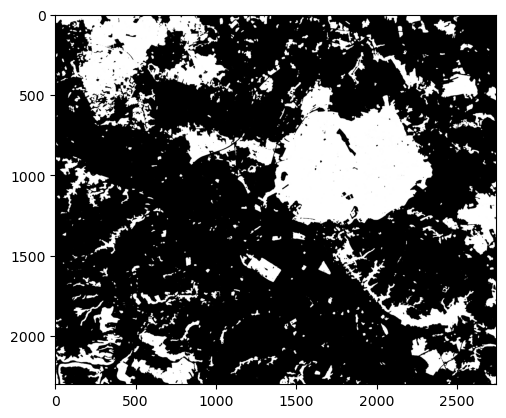

In [21]:
open_image = rasterio.open(file_output_path)
image = open_image.read(1)
plt.imshow(image, cmap='gray')
open_image.close()